# Objectives

    -Load the raw dataset
    -Remove duplicates
    -Handle missing values
    -Clean the price column
    -Clean the milage column
    -Convert data types
    -Detect and treat outliers
    -Perform feature engineering
    -Save the cleaned dataset

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
print("Lieraries Imported Successfully")

Lieraries Imported Successfully


In [2]:
df = pd.read_csv("../data/raw/used_cars.csv")

print(df.shape)

(4009, 12)


In [3]:
data = df.copy()
print("Dataset copied succesfully")

Dataset copied succesfully


In [4]:
missing = pd.DataFrame({
    "Missing": data.isnull().sum(),
    "Percentage": round((data.isnull().sum()/len(data))*100,2)
})

missing.sort_values("Percentage", ascending=False)

,Missing,Percentage
clean_title,596,14.87
fuel_type,170,4.24
accident,113,2.82
brand,0,0.00
milage,0,0.00
model_year,0,0.00
model,0,0.00
engine,0,0.00
ext_col,0,0.00
transmission,0,0.00


In [8]:
print("Before Duplicates:", data.shape)

data.drop_duplicates(inplace=True)

print("After Duplicates :", data.shape)

Before Duplicates: (4009, 12)
After Duplicates : (4009, 12)


In [11]:
# Clean Target Variables
data["price"] = (
    data["price"]
    .astype(str)
    .str.replace("$","", regex=False)
    .str.replace(",","", regex=False)
)

data["price"] = pd.to_numeric(
    data["price"],
    errors="coerce"
)

print("Target Variables Cleaned Successfully")
data["price"].head(20)


Target Variables Cleaned Successfully


0      10300
1      38005
2      54598
3      15500
4      34999
5      14798
6      31000
7       7300
8      41927
9      69950
10     73897
11    184606
12     53500
13     62000
14     47998
15     29990
16    250000
17     16800
18     11000
19     68750
Name: price, dtype: int64

In [14]:
# Clean Milage
data["milage"] = (
    data["milage"]
    .astype(str)
    .str.replace(",","", regex=False)
    .str.replace(" mi.","", regex=False)
)

data["milage"] = pd.to_numeric(
    data["milage"],
    errors="coerce"
)
print("milage  Cleaned Successfully")
data["milage"].head(10)

milage  Cleaned Successfully
0     51,000 mi.
1     34,742 mi.
2     22,372 mi.
3     88,900 mi.
4      9,835 mi.
5    136,397 mi.
6     84,000 mi.
7    242,000 mi.
8     23,436 mi.
9     34,000 mi.
Name: milage, dtype: object


0     51000
1     34742
2     22372
3     88900
4      9835
5    136397
6     84000
7    242000
8     23436
9     34000
Name: milage, dtype: int64

In [15]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   int64 
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   int64 
dtypes: int64(3), object(9)
memory usage: 376.0+ KB


In [18]:
# Handle Missing Values

# Numerical Columns
numeric_cols = data.select_dtypes(include=np.number).columns
for col in numeric_cols:
    data[col].fillna(data[col].median(), inplace=True)

# Categorical Columns
categorical_cols = data.select_dtypes(include="object").columns
for col in categorical_cols:
    data[col].fillna(data[col].mode()[0], inplace=True)

data.isnull().sum()

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64

In [23]:
# Remove Impossible Values
data = data[data["price"] > 0]
data = data[data["model_year"] >= 1980]
data = data[data["milage"] >= 0]

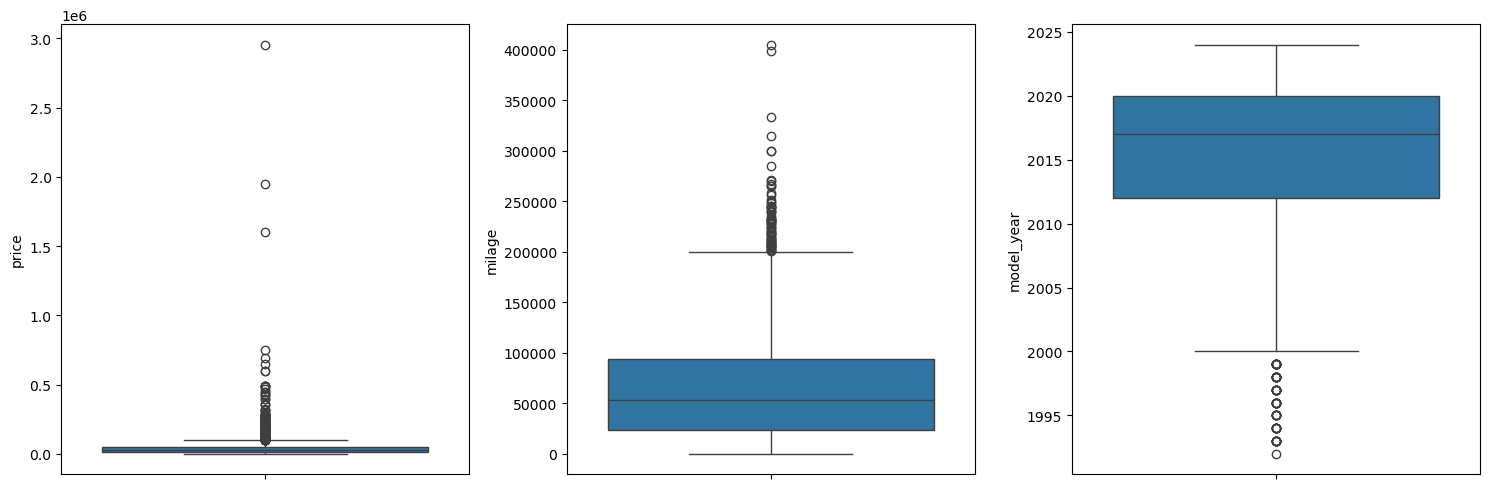

In [24]:
# Detect Outliers
numerical = [
    "price",
    "milage",
    "model_year"]

plt.figure(figsize=(15,5))
for i,col in enumerate(numerical):
    plt.subplot(1,3,i+1)
    sns.boxplot(y=data[col])

plt.tight_layout()
plt.show()

In [27]:
# Handle Outliers Using IQR
def remove_outliers(df,column):
    Q1=df[column].quantile(0.25)
    Q3=df[column].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR

    return df[(df[column]>=lower)&(df[column]<=upper)]

for col in numerical:
    data=remove_outliers(data,col)

In [28]:
# Feature Engineering
CURRENT_YEAR = 2026

data["car_age"] = CURRENT_YEAR-data["model_year"]

In [30]:
data["milage_per_year"] = data["milage"]/(data["car_age"]+1)

In [31]:
luxury = [
    "Mercedes-Benz",
    "BMW",
    "Audi",
    "Porsche",
    "Lexus",
    "Land",
    "Jaguar",
    "Bentley",
    "Maserati",
    "Tesla"
]

data["luxury_brand"] = (
    data["brand"]
    .isin(luxury)
    .astype(int)
)

In [32]:
def age_category(age):

    if age<=3:
        return "New"

    elif age<=8:
        return "Medium"

    else:
        return "Old"

data["vehicle_age"] = data["car_age"].apply(age_category)

In [33]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3642 entries, 0 to 4008
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   brand            3642 non-null   object 
 1   model            3642 non-null   object 
 2   model_year       3642 non-null   int64  
 3   milage           3642 non-null   int64  
 4   fuel_type        3642 non-null   object 
 5   engine           3642 non-null   object 
 6   transmission     3642 non-null   object 
 7   ext_col          3642 non-null   object 
 8   int_col          3642 non-null   object 
 9   accident         3642 non-null   object 
 10  clean_title      3642 non-null   object 
 11  price            3642 non-null   int64  
 12  car_age          3642 non-null   int64  
 13  milage_per_year  3642 non-null   float64
 14  luxury_brand     3642 non-null   int64  
 15  vehicle_age      3642 non-null   object 
dtypes: float64(1), int64(5), object(10)
memory usage: 483.7+ KB
None


In [34]:
data.to_csv(
    "../data/processed/used_cars_clean.csv",
    index=False
)

In [35]:
# Final Summary
print("Final Shape:",data.shape)
print("\nMissing Values")
print(data.isnull().sum())
print("\nDuplicate Records")
print(data.duplicated().sum())

Final Shape: (3642, 16)

Missing Values
brand              0
model              0
model_year         0
milage             0
fuel_type          0
engine             0
transmission       0
ext_col            0
int_col            0
accident           0
clean_title        0
price              0
car_age            0
milage_per_year    0
luxury_brand       0
vehicle_age        0
dtype: int64

Duplicate Records
0
